In [2]:
sheng_dict = {
    '金': ['水'],
    '木': ['火'],
    '水': ['木'],
    '火': ['土'],
    '土': ['金']
    
}
ke_dict = {
    '金': ['木'],
    '木': ['土'],
    '水': ['火'],
    '火': ['金'],
    '土': ['水']
}

('niangan', 'yuezi')
(1, 1)
('nianzi', 'niangan')
(0, 1)
('nianzi', 'yuegan')
(1, 1)
('nianzi', 'rigan')
(2, 1)
('nianzi', 'rizi')
(2, 0)
('nianzi', 'shizi')
(3, 0)
('yuegan', 'yuezi')
(0, 1)
('yuezi', 'rizi')
(1, 0)
('yuezi', 'nianzi')
(1, 0)
('yuezi', 'shigan')
(2, 1)
('yuezi', 'shizi')
(2, 0)
('rigan', 'yuezi')
(1, 1)
('rizi', 'yuezi')
(1, 0)
('shigan', 'niangan')
(3, 0)
('shigan', 'yuegan')
(2, 0)
('shigan', 'rigan')
(1, 0)
('shigan', 'rizi')
(1, 1)
('shigan', 'shizi')
(0, 1)
('shizi', 'niangan')
(3, 1)
('shizi', 'yuegan')
(2, 1)
('shizi', 'rigan')
(1, 1)
('shizi', 'rizi')
(1, 0)


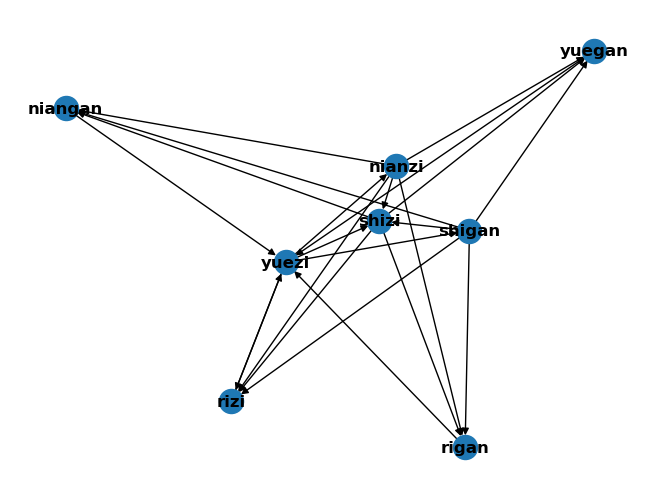

In [6]:
import networkx as nx




# 用 丙子 丁酉 丁巳 壬寅 创建一个有向图
graph = nx.DiGraph()

# 添加节点
graph.add_node('niangan', 字='丙', 陰陽='陽', 屬性='火',十神='劫財')
graph.add_node('nianzi', 字='子', 陰陽='陰', 屬性='水',十神='七殺')
graph.add_node('yuegan', 字='丁', 陰陽='陽', 屬性='火',十神='比肩')
graph.add_node('yuezi', 字='酉', 陰陽='陽', 屬性='金',十神='偏財')
graph.add_node('rigan', 字='丁', 陰陽='陽', 屬性='火',十神='日主')
graph.add_node('rizi', 字='巳', 陰陽='陽', 屬性='火',十神='劫財')
graph.add_node('shigan', 字='壬', 陰陽='陰', 屬性='水',十神='正官')
graph.add_node('shizi', 字='寅', 陰陽='陽', 屬性='木',十神='正印')
# 添加其他节点...

# 添加边
graph.add_edge('yuezi', 'rizi', 關係='半三合', d=(1,0),屬性='金')
graph.add_edge('rizi', 'yuezi', 關係='半三合', d=(1,0),屬性='金')



# 添加其他边...

# 输出图结构信息
# print(graph.nodes)
# print(graph.edges)

# 添加边和距离属性
position_matrix = {
    'shizi': (0, 0),
    'rizi': (1, 0),
    'yuezi': (2, 0),
    'nianzi': (3, 0),
    'shigan': (0, 1),
    'rigan': (1, 1),
    'yuegan': (2, 1),
    'niangan': (3, 1)
}

for node in graph.nodes:
    for neighbor in graph.nodes:
        if node != neighbor:
            node_position = position_matrix[node]
            neighbor_position = position_matrix[neighbor]
            dx = abs(neighbor_position[0] - node_position[0])
            dy = abs(neighbor_position[1] - node_position[1])
            d = (dx, dy)
            # if neighbor_position[0] >= node_position[0] and neighbor_position[1] >= node_position[1]:
            #     d = (dx, dy)
            # else:
            #     d = (-dx, -dy)
            node_attribute = graph.nodes[node]['屬性']
            neighbor_attribute = graph.nodes[neighbor]['屬性']
            if neighbor_attribute in sheng_dict.get(node_attribute, []):
                graph.add_edge(node, neighbor, 關係='生', d=d)
            elif neighbor_attribute in ke_dict.get(node_attribute, []):
                graph.add_edge(node, neighbor, 關係='克', d=d)




for edge in graph.edges:
    print(edge)
    print(graph.edges[edge]['d'])
#draw the graph
nx.draw(graph, with_labels=True, font_weight='bold')






In [7]:
import numpy as np

# Get the nodes in the graph
nodes = sorted(graph.nodes)
num_nodes = len(nodes)

# Create an empty adjacency matrix
adj_matrix = np.zeros((num_nodes, num_nodes), dtype=int)

# Fill the adjacency matrix with edge information
for source, target in graph.edges:
    source_idx = nodes.index(source)
    target_idx = nodes.index(target)
    adj_matrix[source_idx, target_idx] = 1

# Print the adjacency matrix
print(adj_matrix)


[[0 0 0 0 0 0 0 1]
 [1 0 1 1 0 1 1 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1]
 [1 0 1 1 0 1 1 0]
 [1 0 1 1 0 0 1 0]
 [0 0 0 0 0 0 0 1]
 [0 1 0 1 1 1 0 0]]


In [8]:
import numpy as np

# Define the nodes in the graph
nodes = ['shizi', 'rizi', 'yuezi', 'nianzi', 'shigan', 'rigan', 'yuegan', 'niangan']

# Create an empty adjacency matrix
adj_matrix = np.zeros((len(nodes), len(nodes)), dtype=int)

# Populate the adjacency matrix based on the graph edges
for edge in graph.edges:
    source = nodes.index(edge[0])
    target = nodes.index(edge[1])
    adj_matrix[source, target] = 1

# Print the adjacency matrix
print(adj_matrix)


[[0 1 0 0 0 1 1 1]
 [0 0 1 0 0 0 0 0]
 [1 1 0 1 1 0 0 0]
 [1 1 0 0 0 1 1 1]
 [1 1 0 0 0 1 1 1]
 [0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]]


In [10]:
import pandas as pd

# Create an empty DataFrame
df = pd.DataFrame(columns=['Source', 'Target', '關係', 'd', '屬性', '字', '陰陽', '十神'])

# Iterate over the edges of the graph
for edge in graph.edges:
    source = edge[0]
    target = edge[1]
    關係 = graph.edges[edge]['關係']
    d = graph.edges[edge]['d']
    
    # Get the node attributes
    attributes_source = graph.nodes[source]
    attributes_target = graph.nodes[target]
    
    # Extract the desired attributes
    屬性_source = attributes_source.get('屬性', '')
    屬性_target = attributes_target.get('屬性', '')
    
    字_source = attributes_source.get('字', '')
    陰陽_source = attributes_source.get('陰陽', '')
    十神_source = attributes_source.get('十神', '')
    
    字_target = attributes_target.get('字', '')
    陰陽_target = attributes_target.get('陰陽', '')
    十神_target = attributes_target.get('十神', '')
    
    # Append the row to the DataFrame
    df = df.append({
        'Source': source,
        'Target': target,
        '關係': 關係,
        'd': d,
        '屬性': 屬性_source,
        '字': 字_source,
        '陰陽': 陰陽_source,
        '十神': 十神_source
    }, ignore_index=True)
    
    df = df.append({
        'Source': target,
        'Target': source,
        '關係': 關係,
        'd': d,
        '屬性': 屬性_target,
        '字': 字_target,
        '陰陽': 陰陽_target,
        '十神': 十神_target
    }, ignore_index=True)

# Print the DataFrame
print(df)


     Source   Target   關係       d 屬性  字 陰陽  十神
0   niangan    yuezi    克  (1, 1)  火  丙  陽  劫財
1     yuezi  niangan    克  (1, 1)  金  酉  陽  偏財
2    nianzi  niangan    克  (0, 1)  水  子  陰  七殺
3   niangan   nianzi    克  (0, 1)  火  丙  陽  劫財
4    nianzi   yuegan    克  (1, 1)  水  子  陰  七殺
5    yuegan   nianzi    克  (1, 1)  火  丁  陽  比肩
6    nianzi    rigan    克  (2, 1)  水  子  陰  七殺
7     rigan   nianzi    克  (2, 1)  火  丁  陽  日主
8    nianzi     rizi    克  (2, 0)  水  子  陰  七殺
9      rizi   nianzi    克  (2, 0)  火  巳  陽  劫財
10   nianzi    shizi    生  (3, 0)  水  子  陰  七殺
11    shizi   nianzi    生  (3, 0)  木  寅  陽  正印
12   yuegan    yuezi    克  (0, 1)  火  丁  陽  比肩
13    yuezi   yuegan    克  (0, 1)  金  酉  陽  偏財
14    yuezi     rizi  半三合  (1, 0)  金  酉  陽  偏財
15     rizi    yuezi  半三合  (1, 0)  火  巳  陽  劫財
16    yuezi   nianzi    生  (1, 0)  金  酉  陽  偏財
17   nianzi    yuezi    生  (1, 0)  水  子  陰  七殺
18    yuezi   shigan    生  (2, 1)  金  酉  陽  偏財
19   shigan    yuezi    生  (2, 1)  水  壬  陰  正官
20    yuezi  

C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11920\2432840558.py:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11920\2432840558.py:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11920\2432840558.py:30: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11920\2432840558.py:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11920\2432840558.py:30: FutureWarning: The frame.append method is 

In [13]:
import pandas as pd

# Create an empty DataFrame
df = pd.DataFrame()

# Iterate over the nodes of the graph
for node in graph.nodes:
    # Get the node attributes
    attributes = graph.nodes[node]
    
    # Create a dictionary to store the flattened attributes
    node_dict = {}
    
    # Iterate over the attributes of the node
    for attr_key, attr_value in attributes.items():
        node_dict[attr_key] = attr_value
    
    # Add the node attributes to the DataFrame as a single row
    df = df.append(node_dict, ignore_index=True)

# Extract the edge information
edges = [(edge[0], edge[1], graph.edges[edge]['關係'], graph.edges[edge]['d']) for edge in graph.edges]

# Add the edges to the DataFrame as a single row
df['Edges'] = [edges]

# Print the DataFrame
print(df)


C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11920\3809867663.py:19: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(node_dict, ignore_index=True)
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11920\3809867663.py:19: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(node_dict, ignore_index=True)
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11920\3809867663.py:19: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(node_dict, ignore_index=True)
C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_11920\3809867663.py:19: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append(node_dict, ignore_index=True)


ValueError: Length of values (1) does not match length of index (8)

In [14]:
import pandas as pd

# Create an empty DataFrame
df = pd.DataFrame()

# Extract the node information
nodes = []
for node in graph.nodes:
    attributes = graph.nodes[node]
    node_dict = {'Node': node}
    node_dict.update(attributes)
    nodes.append(node_dict)

# Extract the edge information
edges = []
for edge in graph.edges:
    source, target = edge
    attributes = graph.edges[edge]
    edge_dict = {'Source': source, 'Target': target}
    edge_dict.update(attributes)
    edges.append(edge_dict)

# Create DataFrames for nodes and edges
nodes_df = pd.DataFrame(nodes)
edges_df = pd.DataFrame(edges)

# Merge nodes and edges into a single DataFrame
df = pd.merge(nodes_df, edges_df, how='outer')

# Print the DataFrame
print(df)


       Node    字   陰陽   屬性   十神   Source   Target   關係       d
0   niangan    丙    陽    火   劫財      NaN      NaN  NaN     NaN
1    yuegan    丁    陽    火   比肩      NaN      NaN  NaN     NaN
2     rigan    丁    陽    火   日主      NaN      NaN  NaN     NaN
3      rizi    巳    陽    火   劫財      NaN      NaN  NaN     NaN
4    nianzi    子    陰    水   七殺      NaN      NaN  NaN     NaN
5    shigan    壬    陰    水   正官      NaN      NaN  NaN     NaN
6     yuezi    酉    陽    金   偏財    yuezi     rizi  半三合  (1, 0)
7     yuezi    酉    陽    金   偏財     rizi    yuezi    克  (1, 0)
8     shizi    寅    陽    木   正印      NaN      NaN  NaN     NaN
9       NaN  NaN  NaN  NaN  NaN  niangan    yuezi    克  (1, 1)
10      NaN  NaN  NaN  NaN  NaN   nianzi  niangan    克  (0, 1)
11      NaN  NaN  NaN  NaN  NaN   nianzi   yuegan    克  (1, 1)
12      NaN  NaN  NaN  NaN  NaN   nianzi    rigan    克  (2, 1)
13      NaN  NaN  NaN  NaN  NaN   nianzi     rizi    克  (2, 0)
14      NaN  NaN  NaN  NaN  NaN   nianzi    shizi    生 

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader

# 定义图神经网络模型
class GraphModel(nn.Module):
    def __init__(self, num_features):
        super(GraphModel, self).__init__()
        self.num_features = num_features
        self.fc = nn.Linear(num_features, 1)

    def forward(self, data):
        x = data.x.float()
        x = self.fc(x)
        return torch.sigmoid(x)

# 创建八字数据
eight_words = [
    {
        '年干': {'字': '丙', '陰陽': '陽', '屬性': '火'},
        '年支': {'字': '子', '陰陽': '陽', '屬性': '水'},
        '月干': {'字': '丁', '陰陽': '陽', '屬性': '火'},
        '月支': {'字': '酉', '陰陽': '陽', '屬性': '金'}
    },
    {
        '年干': {'字': '甲', '陰陽': '陽', '屬性': '木'},
        '年支': {'字': '午', '陰陽': '陽', '屬性': '火'},
        '月干': {'字': '乙', '陰陽': '陰', '屬性': '木'},
        '月支': {'字': '酉', '陰陽': '陽', '屬性': '金'}
    },
    {
        '年干': {'字': '庚', '陰陽': '陽', '屬性': '金'},
        '年支': {'字': '子', '陰陽': '陽', '屬性': '水'},
        '月干': {'字': '癸', '陰陽': '陰', '屬性': '水'},
        '月支': {'字': '亥', '陰陽': '陰', '屬性': '水'}
    }
]

# 创建图数据列表
graph_data_list = []

# 创建有向图并添加节点和边
for eight_word in eight_words:
    graph = nx.DiGraph()
    for key, value in eight_word.items():
        graph.add_node(key, attribute=value)

    graph.add_edge('年干', '年支')
    graph.add_edge('年干', '月干')
    graph.add_edge('月干', '月支')

    graph_data = Data(
        x=torch.tensor([
            [1, 0, 0],  # 年干的特征表示
            [0, 1, 0],  # 年支的特征表示
            [0, 0, 1],  # 月干的特征表示
            [0, 0, 0]   # 月支的特征表示
        ]),
        edge_index=torch.tensor([
            [0, 1, 0, 2],  # 边的索引表示
            [1, 0, 2, 3]
        ]),
        y=torch.tensor([1]),  # 目标变量
        num_nodes=4  # 节点数量
    )
    graph_data_list.append(graph_data)

# Create the dataset and data loader
dataset = DataLoader(graph_data_list, batch_size=1, shuffle=True)

# Define the model and optimizer
model = GraphModel(num_features=3)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training and classification task
for data in dataset:
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, data.y.float())
    loss.backward()
    optimizer.step()

    # Output the predicted labels
    predicted_labels = torch.round(output)
    print("Predicted labels:", predicted_labels)

c:\Users\TOSHIBA\anaconda3\lib\site-packages\torch_geometric\deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


ValueError: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([4, 1])) is deprecated. Please ensure they have the same size.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader
import networkx as nx

# Define the graph model
class GraphModel(nn.Module):
    def __init__(self, num_features):
        super(GraphModel, self).__init__()
        self.num_features = num_features
        self.fc = nn.Linear(num_features, 1)

    def forward(self, data):
        x = data.x.float()
        x = self.fc(x)
        return torch.sigmoid(x)

# Create the eight-word data
eight_words = [
    {
        '年干': {'字': '丙', '陰陽': '陽', '屬性': '火'},
        '年支': {'字': '子', '陰陽': '陽', '屬性': '水'},
        '月干': {'字': '丁', '陰陽': '陽', '屬性': '火'},
        '月支': {'字': '酉', '陰陽': '陽', '屬性': '金'}
    },
    {
        '年干': {'字': '甲', '陰陽': '陽', '屬性': '木'},
        '年支': {'字': '午', '陰陽': '陽', '屬性': '火'},
        '月干': {'字': '乙', '陰陽': '陰', '屬性': '木'},
        '月支': {'字': '酉', '陰陽': '陽', '屬性': '金'}
    },
    {
        '年干': {'字': '庚', '陰陽': '陽', '屬性': '金'},
        '年支': {'字': '子', '陰陽': '陽', '屬性': '水'},
        '月干': {'字': '癸', '陰陽': '陰', '屬性': '水'},
        '月支': {'字': '亥', '陰陽': '陰', '屬性': '水'}
    }
]

# Create the graph data list
graph_data_list = []

# Create directed graphs and add nodes and edges
for eight_word in eight_words:
    graph = nx.DiGraph()
    for key, value in eight_word.items():
        graph.add_node(key, attribute=value)
    
    graph.add_edge('年干', '年支')
    graph.add_edge('年干', '月干')
    graph.add_edge('月干', '月支')
    
    graph_data = Data(
        x=torch.tensor([
            [1, 0, 0],  # 年干的特征表示
            [0, 1, 0],  # 年支的特征表示
            [0, 0, 1],  # 月干的特征表示
            [0, 0, 0]   # 月支的特征表示
        ]),
        edge_index=torch.tensor([
            [0, 0, 1, 2],  # 边的起始节点
            [1, 2, 3, 3]   # 边的结束节点
        ]),
        y=torch.tensor([[1,0,1]]),  # 目标变量
        num_nodes=4  # 节点数量
    )
    graph_data_list.append(graph_data)

# Create the dataset and data loader
dataset = DataLoader(graph_data_list, batch_size=1, shuffle=True)

# Define the model and optimizer
model = GraphModel(num_features=3)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training and classification task
for data in dataset:
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, data.y)
    loss.backward()
    optimizer.step()

    # Output the predicted labels
    predicted_labels = torch.round(output)
    print("Predicted labels:", predicted_labels)


ValueError: Using a target size (torch.Size([1, 3])) that is different to the input size (torch.Size([4, 1])) is deprecated. Please ensure they have the same size.